# Anticipez les besoins en consommation de bâtiments — Seattle

**Objectif :** prédire la consommation d'énergie (`SiteEnergyUse(kBtu)`) et les émissions de CO₂ (`TotalGHGEmissions`) des bâtiments non résidentiels de Seattle à partir de caractéristiques structurelles : taille, usage, âge, localisation, etc.

## Plan du notebook

1. Chargement et aperçu des données  
2. Filtrage des bâtiments non résidentiels  
3. Suppression des colonnes non pertinentes ou à risque de data leakage  
4. Traitement des valeurs manquantes  
5. Cas particulier de `ENERGYSTARScore`  
6. Contrôle des valeurs incohérentes  
7. Analyse exploratoire finale  
8. Export des datasets nettoyés

## 0. Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math

try:
    from wordcloud import WordCloud
    WORDCLOUD_AVAILABLE = True
except ImportError:
    WORDCLOUD_AVAILABLE = False

from IPython.display import display

sns.set(font_scale=1)
pd.set_option('display.max_columns', None)

## 1. Chargement et aperçu des données

On charge le fichier source puis on vérifie rapidement la taille du jeu de données, les types de variables et les premières lignes.

In [2]:
data = pd.read_csv('Building_Energy.csv')

print(f"Shape initiale : {data.shape}")
print("\nTypes de variables :")
print(data.dtypes.value_counts())

display(data.head())

Shape initiale : (3376, 46)

Types de variables :
float64    22
str        14
int64       8
object      1
bool        1
Name: count, dtype: int64


,OSEBuildingID,DataYear,BuildingType,PrimaryPropertyType,PropertyName,Address,City,State,ZipCode,TaxParcelIdentificationNumber,CouncilDistrictCode,Neighborhood,Latitude,Longitude,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),ListOfAllPropertyUseTypes,LargestPropertyUseType,LargestPropertyUseTypeGFA,SecondLargestPropertyUseType,SecondLargestPropertyUseTypeGFA,ThirdLargestPropertyUseType,ThirdLargestPropertyUseTypeGFA,YearsENERGYSTARCertified,ENERGYSTARScore,SiteEUI(kBtu/sf),SiteEUIWN(kBtu/sf),SourceEUI(kBtu/sf),SourceEUIWN(kBtu/sf),SiteEnergyUse(kBtu),SiteEnergyUseWN(kBtu),SteamUse(kBtu),Electricity(kWh),Electricity(kBtu),NaturalGas(therms),NaturalGas(kBtu),DefaultData,Comments,ComplianceStatus,Outlier,TotalGHGEmissions,GHGEmissionsIntensity
0,1,2016,NonResidential,Hotel,Mayflower park hotel,405 Olive way,Seattle,WA,98101.0,0659000030,7,DOWNTOWN,47.61220,-122.33799,1927,1.0,12,88434,0,88434,Hotel,Hotel,88434.0,NaN,NaN,NaN,NaN,NaN,60.0,81.699997,84.300003,182.500000,189.000000,7226362.5,7456910.0,2003882.00,1.156514e+06,3946027.0,12764.52930,1276453.0,False,NaN,Compliant,NaN,249.98,2.83
1,2,2016,NonResidential,Hotel,Paramount Hotel,724 Pine street,Seattle,WA,98101.0,0659000220,7,DOWNTOWN,47.61317,-122.33393,1996,1.0,11,103566,15064,88502,"Hotel, Parking, Restaurant",Hotel,83880.0,Parking,15064.0,Restaurant,4622.0,NaN,61.0,94.800003,97.900002,176.100006,179.399994,8387933.0,8664479.0,0.00,9.504252e+05,3242851.0,51450.81641,5145082.0,False,NaN,Compliant,NaN,295.86,2.86
2,3,2016,NonResidential,Hotel,5673-The Westin Seattle,1900 5th Avenue,Seattle,WA,98101.0,0659000475,7,DOWNTOWN,47.61393,-122.33810,1969,1.0,41,956110,196718,759392,Hotel,Hotel,756493.0,NaN,NaN,NaN,NaN,NaN,43.0,96.000000,97.699997,241.899994,244.100006,72587024.0,73937112.0,21566554.00,1.451544e+07,49526664.0,14938.00000,1493800.0,False,NaN,Compliant,NaN,2089.28,2.19
3,5,2016,NonResidential,Hotel,HOTEL MAX,620 STEWART ST,Seattle,WA,98101.0,0659000640,7,DOWNTOWN,47.61412,-122.33664,1926,1.0,10,61320,0,61320,Hotel,Hotel,61320.0,NaN,NaN,NaN,NaN,NaN,56.0,110.800003,113.300003,216.199997,224.000000,6794584.0,6946800.5,2214446.25,8.115253e+05,2768924.0,18112.13086,1811213.0,False,NaN,Compliant,NaN,286.43,4.67
4,8,2016,NonResidential,Hotel,WARWICK SEATTLE HOTEL (ID8),401 LENORA ST,Seattle,WA,98121.0,0659000970,7,DOWNTOWN,47.61375,-122.34047,1980,1.0,18,175580,62000,113580,"Hotel, Parking, Swimming Pool",Hotel,123445.0,Parking,68009.0,Swimming Pool,0.0,NaN,75.0,114.800003,118.699997,211.399994,215.600006,14172606.0,14656503.0,0.00,1.573449e+06,5368607.0,88039.98438,8803998.0,False,NaN,Compliant,NaN,505.01,2.88


## 2. Analyse du taux de valeurs manquantes

Avant de supprimer des colonnes, on observe le taux de valeurs manquantes afin d'éviter une suppression trop brutale.

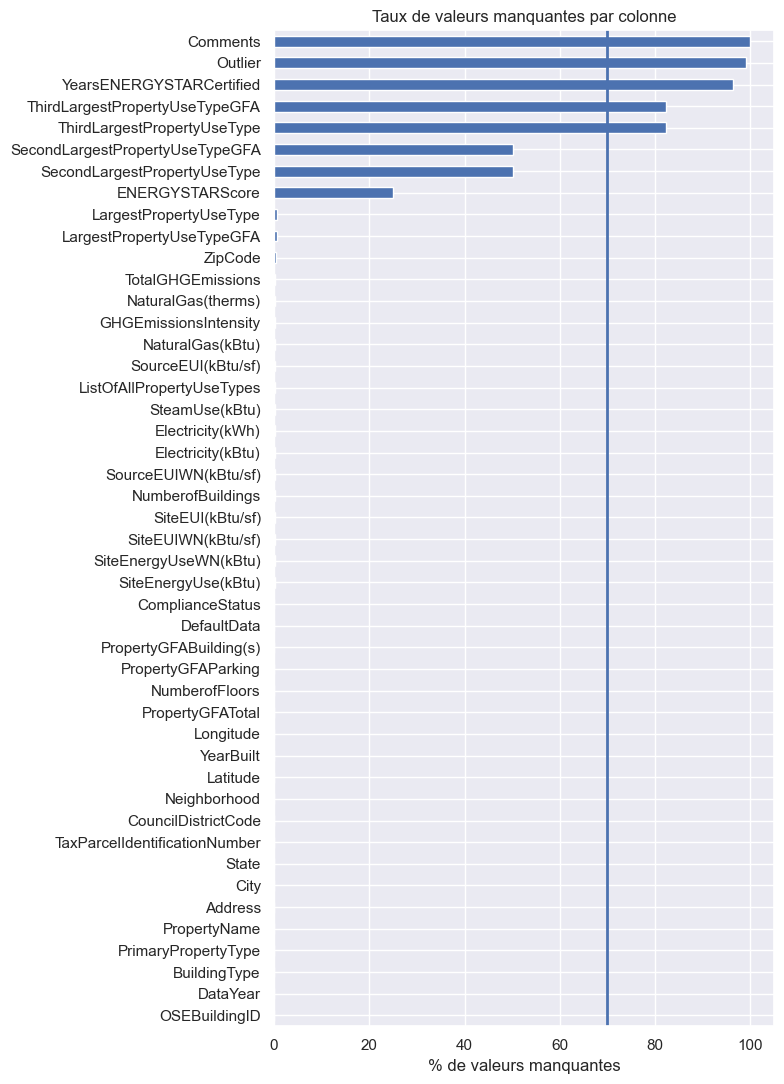

In [4]:
def plot_nan_rates(df, threshold=70):
    """Affiche le taux de valeurs manquantes par colonne."""
    nan_rates = df.isna().mean().mul(100).sort_values()

    plt.figure(figsize=(8, 11))
    nan_rates.plot(kind='barh')
    plt.axvline(x=threshold, ls='-', lw=2)
    plt.xlabel('% de valeurs manquantes')
    plt.title('Taux de valeurs manquantes par colonne')
    plt.tight_layout()
    plt.show()

plot_nan_rates(data, threshold=70)

Les colonnes avec plus de 70 % de valeurs manquantes sont supprimées. Ce seuil permet de retirer les variables très peu renseignées tout en conservant un maximum d'information.

In [5]:
n_cols_before = data.shape[1]

# Garder les colonnes ayant au moins 30 % de valeurs renseignées
data = data.dropna(thresh=int(data.shape[0] * 0.3), axis=1)

n_cols_after = data.shape[1]

print(f"Nombre de colonnes avant suppression : {n_cols_before}")
print(f"Nombre de colonnes après suppression : {n_cols_after}")
print(f"Nombre de colonnes supprimées : {n_cols_before - n_cols_after}")
print(f"Shape après suppression des colonnes très incomplètes : {data.shape}")

Nombre de colonnes avant suppression : 46
Nombre de colonnes après suppression : 41
Nombre de colonnes supprimées : 5
Shape après suppression des colonnes très incomplètes : (3376, 41)


## 3. Filtrage des bâtiments non résidentiels

Le projet concerne les bâtiments non destinés à l'habitation.  
On exclut donc les bâtiments de type `Multifamily` ainsi que les usages principaux correspondant à de l'habitation multifamiliale.

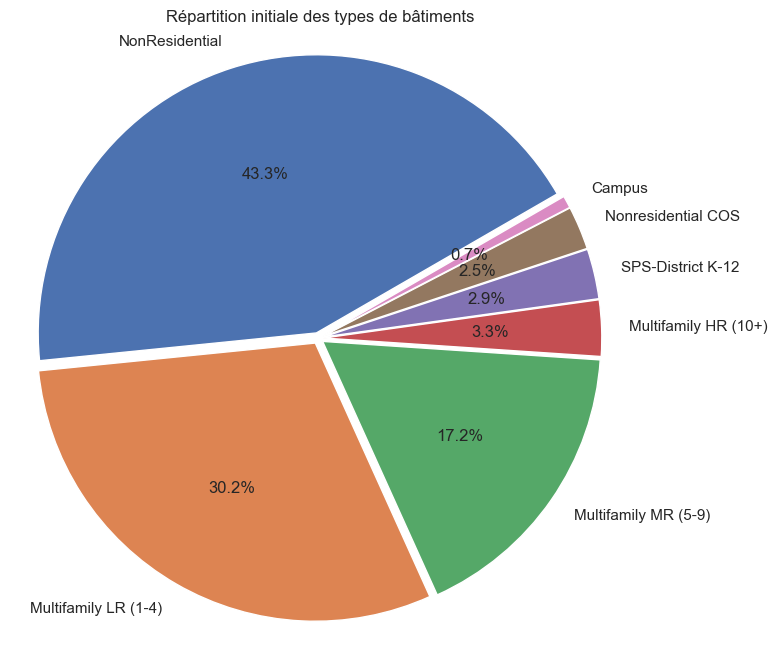

In [6]:
# Répartition initiale des types de bâtiments
building_counts = data['BuildingType'].value_counts().head(7)

fig, ax = plt.subplots(figsize=(8, 8))
ax.pie(
    building_counts,
    labels=building_counts.index,
    explode=[0.02] * len(building_counts),
    autopct='%1.1f%%',
    startangle=30
)
ax.axis('equal')
plt.title('Répartition initiale des types de bâtiments')
plt.show()

In [7]:
n_before_filter = data.shape[0]

# Exclure les bâtiments résidentiels multifamiliaux
data = data[~data['BuildingType'].str.contains('Multifamily', na=False)].copy()

# Exclure les résidences multifamiliales éventuellement présentes dans les campus
if 'LargestPropertyUseType' in data.columns:
    data = data[data['LargestPropertyUseType'] != 'Multifamily Housing'].copy()

n_after_filter = data.shape[0]

print(f"Nombre de lignes avant filtrage : {n_before_filter}")
print(f"Nombre de lignes après filtrage : {n_after_filter}")
print(f"Nombre de lignes supprimées : {n_before_filter - n_after_filter}")
print(f"Pourcentage supprimé : {(n_before_filter - n_after_filter) / n_before_filter * 100:.2f}%")
print(f"Types restants : {data['BuildingType'].unique()}")

Nombre de lignes avant filtrage : 3376
Nombre de lignes après filtrage : 1656
Nombre de lignes supprimées : 1720
Pourcentage supprimé : 50.95%
Types restants : <StringArray>
[    'NonResidential', 'Nonresidential COS',  'SPS-District K-12',
             'Campus',  'Nonresidential WA']
Length: 5, dtype: str


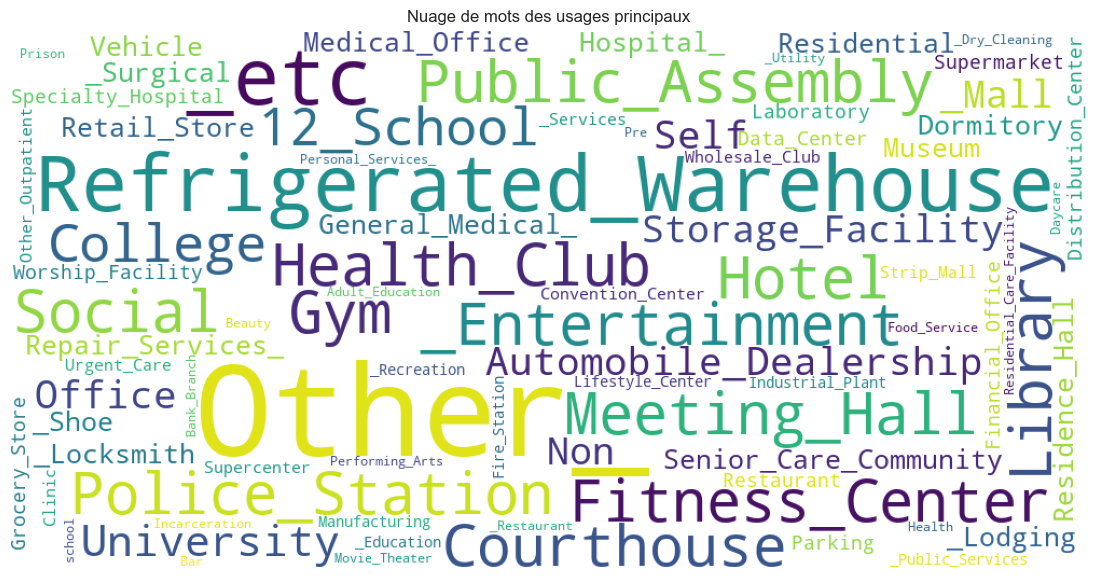

In [8]:
# Visualisation optionnelle des usages principaux
if WORDCLOUD_AVAILABLE:
    use_types = data['LargestPropertyUseType'].dropna().str.replace(' ', '_').unique()
    wc = WordCloud(width=1000, height=500, background_color='white').generate(' '.join(use_types))

    plt.figure(figsize=(14, 7))
    plt.imshow(wc)
    plt.axis('off')
    plt.title("Nuage de mots des usages principaux")
    plt.show()
else:
    print("WordCloud n'est pas installé. Étape ignorée.")

## 4. Suppression des colonnes non pertinentes ou à risque de data leakage

Le modèle doit prédire les consommations et émissions à partir de caractéristiques structurelles des bâtiments.  
Les variables directement liées à la consommation d'énergie ou aux émissions réelles sont supprimées pour éviter le **data leakage**.

### Création de l'âge du bâtiment

La variable `YearBuilt` indique l'année de construction.  
On crée `Agebuilding`, plus directement interprétable, puis on supprimera `YearBuilt`.

In [9]:
# Création de la variable Agebuilding à partir de l'année de construction
data['Agebuilding'] = data['DataYear'] - data['YearBuilt']

### Définition des familles de colonnes à supprimer

Les colonnes sont regroupées par raison de suppression : identifiants, variables administratives peu exploitables, colonnes textuelles complexes, variables redondantes et colonnes à risque de data leakage.

In [10]:
# Variables cibles conservées pour la modélisation
target_cols = [
    'SiteEnergyUse(kBtu)',
    'TotalGHGEmissions'
]

# Colonnes identifiants, administratives ou peu exploitables directement
id_cols = [
    'OSEBuildingID',
    'DataYear',
    'TaxParcelIdentificationNumber',
    'PropertyName',
    'Address',
    'City',
    'State'
]

# Colonnes utilisées pour le contrôle qualité ou trop difficiles à exploiter directement
quality_or_text_cols = [
    'DefaultData',
    'ComplianceStatus',
    'ListOfAllPropertyUseTypes'
]

# Colonnes géographiques redondantes ou à forte cardinalité
geo_cols = [
    'CouncilDistrictCode',
    'ZipCode',
    'Neighborhood'
]

# Année de construction supprimée après création de Agebuilding
date_cols = [
    'YearBuilt'
]

# Colonnes directement liées à la consommation d'énergie ou aux émissions
# Elles sont supprimées pour éviter le data leakage.
leakage_cols = [
    'SiteEUI(kBtu/sf)',
    'SiteEUIWN(kBtu/sf)',
    'SourceEUI(kBtu/sf)',
    'SourceEUIWN(kBtu/sf)',
    'SiteEnergyUseWN(kBtu)',
    'SteamUse(kBtu)',
    'Electricity(kWh)',
    'Electricity(kBtu)',
    'NaturalGas(therms)',
    'NaturalGas(kBtu)',
    'GHGEmissionsIntensity'
]

# Colonne de surface fortement redondante avec d'autres variables GFA
correlated_cols = [
    'PropertyGFABuilding(s)'
]

In [11]:
# Regroupement de toutes les colonnes à supprimer
cols_to_drop = (
    id_cols
    + quality_or_text_cols
    + geo_cols
    + date_cols
    + leakage_cols
    + correlated_cols
)

# Conservation uniquement des colonnes présentes dans le dataframe
cols_to_drop = [col for col in cols_to_drop if col in data.columns]

# Suppression des colonnes
n_cols_before = data.shape[1]
data = data.drop(columns=cols_to_drop)
n_cols_after = data.shape[1]

print(f"Nombre de colonnes avant suppression : {n_cols_before}")
print(f"Nombre de colonnes après suppression : {n_cols_after}")
print(f"Nombre de colonnes supprimées : {n_cols_before - n_cols_after}")
print(f"Shape après suppression des colonnes : {data.shape}")

Nombre de colonnes avant suppression : 42
Nombre de colonnes après suppression : 16
Nombre de colonnes supprimées : 26
Shape après suppression des colonnes : (1656, 16)


### Vérifications après suppression des colonnes

On vérifie que les cibles sont toujours présentes et qu'il ne reste plus de variables à risque de data leakage.

In [12]:
# Conversion des coordonnées géographiques en variables numériques
if {'Latitude', 'Longitude'}.issubset(data.columns):
    data[['Latitude', 'Longitude']] = data[['Latitude', 'Longitude']].astype('float64')

# Vérification de la présence des variables cibles
for target in target_cols:
    if target in data.columns:
        print(f"Target présente : {target}")
    else:
        print(f"Target absente : {target}")

# Vérification que les colonnes à risque de data leakage ont bien été supprimées
remaining_leakage_cols = [col for col in leakage_cols if col in data.columns]

if len(remaining_leakage_cols) == 0:
    print("\nAucune colonne de data leakage restante.")
else:
    print("\nAttention, colonnes de leakage encore présentes :")
    for col in remaining_leakage_cols:
        print("-", col)

display(data.head())

Target présente : SiteEnergyUse(kBtu)
Target présente : TotalGHGEmissions

Aucune colonne de data leakage restante.


,BuildingType,PrimaryPropertyType,Latitude,Longitude,NumberofBuildings,NumberofFloors,PropertyGFATotal,PropertyGFAParking,LargestPropertyUseType,LargestPropertyUseTypeGFA,SecondLargestPropertyUseType,SecondLargestPropertyUseTypeGFA,ENERGYSTARScore,SiteEnergyUse(kBtu),TotalGHGEmissions,Agebuilding
0,NonResidential,Hotel,47.61220,-122.33799,1.0,12,88434,0,Hotel,88434.0,NaN,NaN,60.0,7226362.5,249.98,89
1,NonResidential,Hotel,47.61317,-122.33393,1.0,11,103566,15064,Hotel,83880.0,Parking,15064.0,61.0,8387933.0,295.86,20
2,NonResidential,Hotel,47.61393,-122.33810,1.0,41,956110,196718,Hotel,756493.0,NaN,NaN,43.0,72587024.0,2089.28,47
3,NonResidential,Hotel,47.61412,-122.33664,1.0,10,61320,0,Hotel,61320.0,NaN,NaN,56.0,6794584.0,286.43,90
4,NonResidential,Hotel,47.61375,-122.34047,1.0,18,175580,62000,Hotel,123445.0,Parking,68009.0,75.0,14172606.0,505.01,36


In [13]:
# Identification des variables numériques et catégorielles restantes
numeric_cols = data.select_dtypes(include=['number']).columns.tolist()

categorical_cols = data.select_dtypes(
    include=['object', 'string', 'category', 'bool']
).columns.tolist()

print(f"Nombre de variables numériques : {len(numeric_cols)}")
print(f"Nombre de variables catégorielles : {len(categorical_cols)}")

print("\nVariables numériques :")
for col in numeric_cols:
    print("-", col)

print("\nVariables catégorielles :")
for col in categorical_cols:
    print("-", col)

Nombre de variables numériques : 12
Nombre de variables catégorielles : 4

Variables numériques :
- Latitude
- Longitude
- NumberofBuildings
- NumberofFloors
- PropertyGFATotal
- PropertyGFAParking
- LargestPropertyUseTypeGFA
- SecondLargestPropertyUseTypeGFA
- ENERGYSTARScore
- SiteEnergyUse(kBtu)
- TotalGHGEmissions
- Agebuilding

Variables catégorielles :
- BuildingType
- PrimaryPropertyType
- LargestPropertyUseType
- SecondLargestPropertyUseType


## 5. Analyse et traitement des valeurs manquantes

On analyse les valeurs manquantes restantes après la suppression des colonnes.  
Les traitements sont ensuite décidés selon le sens métier des variables.

In [14]:
missing_values = pd.DataFrame({
    'nb_missing': data.isna().sum(),
    'pct_missing': data.isna().mean() * 100
})

missing_values = missing_values[missing_values['nb_missing'] > 0]
missing_values = missing_values.sort_values(by='pct_missing', ascending=False)

display(missing_values)

rows_with_missing = data.isna().any(axis=1).sum()
print(f"Nombre de lignes avec au moins une valeur manquante : {rows_with_missing}")
print(f"Pourcentage de lignes concernées : {rows_with_missing / len(data) * 100:.2f}%")

,nb_missing,pct_missing
SecondLargestPropertyUseType,812,49.033816
SecondLargestPropertyUseTypeGFA,812,49.033816
ENERGYSTARScore,566,34.178744
LargestPropertyUseType,6,0.362319
LargestPropertyUseTypeGFA,6,0.362319
NumberofBuildings,2,0.120773
SiteEnergyUse(kBtu),2,0.120773
TotalGHGEmissions,2,0.120773


Nombre de lignes avec au moins une valeur manquante : 1158
Pourcentage de lignes concernées : 69.93%


### Traitement des valeurs manquantes et harmonisation des catégories

Les lignes sans variable cible sont supprimées, car elles ne peuvent pas être utilisées dans un apprentissage supervisé.

Pour les variables d'usage secondaire, les valeurs manquantes sont interprétées comme une absence de deuxième usage déclaré : la modalité devient `No second use` et la surface associée vaut 0.

Les rares valeurs manquantes de l'usage principal sont imputées à partir de `PrimaryPropertyType`, car ces deux variables décrivent l'usage principal du bâtiment à des niveaux de détail proches.

In [15]:
n_before_missing = data.shape[0]

# Nettoyage léger des formats dans les variables catégorielles
cat_cols = data.select_dtypes(include=['object', 'string', 'category']).columns
data[cat_cols] = data[cat_cols].replace(
    {r'\n': '', r' / ': '/', r' - ': '-'},
    regex=True
)

# Harmonisation de certains libellés d'usage
cols_use_type = [
    'PrimaryPropertyType',
    'LargestPropertyUseType',
    'SecondLargestPropertyUseType'
]

for col in cols_use_type:
    if col in data.columns:
        data[col] = data[col].replace(
            'Small- and Mid-Sized Office',
            'Office'
        )

# Suppression des lignes pour lesquelles les variables cibles sont manquantes
data = data.dropna(subset=target_cols)

# Imputation des rares valeurs manquantes de l'usage principal
if {'LargestPropertyUseType', 'PrimaryPropertyType'}.issubset(data.columns):
    mask_largest_missing = data['LargestPropertyUseType'].isna()
    data.loc[mask_largest_missing, 'LargestPropertyUseType'] = data.loc[
        mask_largest_missing, 'PrimaryPropertyType'
    ]

# Si la surface du principal usage est manquante, on utilise la surface totale
if {'LargestPropertyUseTypeGFA', 'PropertyGFATotal'}.issubset(data.columns):
    data['LargestPropertyUseTypeGFA'] = data['LargestPropertyUseTypeGFA'].fillna(
        data['PropertyGFATotal']
    )

# Absence de second usage : modalité explicite et surface associée égale à 0
if 'SecondLargestPropertyUseType' in data.columns:
    data['SecondLargestPropertyUseType'] = data['SecondLargestPropertyUseType'].fillna(
        'No second use'
    )

if 'SecondLargestPropertyUseTypeGFA' in data.columns:
    data['SecondLargestPropertyUseTypeGFA'] = data['SecondLargestPropertyUseTypeGFA'].fillna(0)

# Imputation du nombre de bâtiments par la médiane
if 'NumberofBuildings' in data.columns:
    data['NumberofBuildings'] = data['NumberofBuildings'].fillna(
        data['NumberofBuildings'].median()
    )

n_after_missing = data.shape[0]

print(f"Nombre de lignes avant traitement : {n_before_missing}")
print(f"Nombre de lignes après traitement : {n_after_missing}")
print(f"Nombre de lignes supprimées : {n_before_missing - n_after_missing}")
print(f"Pourcentage de lignes supprimées : {(n_before_missing - n_after_missing) / n_before_missing * 100:.2f}%")

Nombre de lignes avant traitement : 1656
Nombre de lignes après traitement : 1654
Nombre de lignes supprimées : 2
Pourcentage de lignes supprimées : 0.12%


In [ ]:
# Vérification finale des valeurs manquantes après traitement
missing_after = data.isna().sum()
display(missing_after[missing_after > 0])

## 6. Cas particulier de `ENERGYSTARScore`

`ENERGYSTARScore` est une variable informative, mais elle est liée à la performance énergétique du bâtiment.  
On crée donc deux versions du dataset :

- une version principale sans `ENERGYSTARScore` ;
- une version secondaire avec `ENERGYSTARScore`, utilisée plus tard pour mesurer son impact.

In [16]:
# Dataset principal : sans ENERGYSTARScore
data_without_score = data.drop(columns=['ENERGYSTARScore'], errors='ignore').copy()

# Dataset secondaire : avec ENERGYSTARScore
data_with_score = data.copy()

print(f"Shape sans ENERGYSTARScore : {data_without_score.shape}")
print(f"Shape avec ENERGYSTARScore : {data_with_score.shape}")

Shape sans ENERGYSTARScore : (1654, 15)
Shape avec ENERGYSTARScore : (1654, 16)


## 7. Contrôle des valeurs incohérentes

On vérifie les valeurs impossibles ou très suspectes sans supprimer automatiquement les valeurs extrêmes.  
Les valeurs extrêmes peuvent correspondre à des bâtiments réels de grande taille.

In [17]:
cols_to_check = [
    'PropertyGFATotal',
    'PropertyGFAParking',
    'LargestPropertyUseTypeGFA',
    'SecondLargestPropertyUseTypeGFA',
    'NumberofBuildings',
    'NumberofFloors',
    'Agebuilding',
    'SiteEnergyUse(kBtu)',
    'TotalGHGEmissions'
]

cols_to_check = [col for col in cols_to_check if col in data_without_score.columns]

display(data_without_score[cols_to_check].describe().T[['min', '25%', '50%', '75%', 'max']])

,min,25%,50%,75%,max
PropertyGFATotal,11285.0,2.943725e+04,49489.500,1.060308e+05,9.320156e+06
PropertyGFAParking,0.0,0.000000e+00,0.000,0.000000e+00,5.126080e+05
LargestPropertyUseTypeGFA,5656.0,2.565950e+04,44039.000,9.209825e+04,9.320156e+06
SecondLargestPropertyUseTypeGFA,0.0,0.000000e+00,0.000,1.261900e+04,6.867500e+05
NumberofBuildings,0.0,1.000000e+00,1.000,1.000000e+00,1.110000e+02
NumberofFloors,0.0,1.000000e+00,2.000,4.000000e+00,9.900000e+01
Agebuilding,1.0,2.700000e+01,51.000,8.600000e+01,1.160000e+02
SiteEnergyUse(kBtu),0.0,1.233141e+06,2557796.375,6.917429e+06,8.739237e+08
TotalGHGEmissions,-0.8,1.996750e+01,49.675,1.441425e+02,1.687098e+04


### Traitement de `NumberofBuildings = 0` et des émissions négatives

Des lignes présentent `NumberofBuildings = 0`, alors qu'elles ont une surface, une consommation et des émissions renseignées.  
On considère donc qu'il s'agit d'une valeur mal renseignée et on remplace `0` par `1`, valeur minimale cohérente.

En revanche, les émissions négatives sont supprimées, car elles ne sont pas interprétables physiquement.

In [18]:
# Comptage des valeurs incohérentes ou suspectes
mask_nb_buildings_zero = data_without_score['NumberofBuildings'] == 0
mask_ghg_negative = data_without_score['TotalGHGEmissions'] < 0

print(f"Lignes avec NumberofBuildings = 0 : {mask_nb_buildings_zero.sum()}")
print(f"Lignes avec TotalGHGEmissions < 0 : {mask_ghg_negative.sum()}")

# Remplacement de NumberofBuildings = 0 par 1 dans les deux datasets
data_without_score.loc[data_without_score['NumberofBuildings'] == 0, 'NumberofBuildings'] = 1
data_with_score.loc[data_with_score['NumberofBuildings'] == 0, 'NumberofBuildings'] = 1

# Suppression des lignes avec émissions négatives dans les deux datasets
n_before = data_without_score.shape[0]

mask_ghg_negative = data_without_score['TotalGHGEmissions'] < 0

data_without_score = data_without_score.loc[~mask_ghg_negative].copy()
data_with_score = data_with_score.loc[data_without_score.index].copy()

n_after = data_without_score.shape[0]

print(f"\nNombre de lignes avant suppression : {n_before}")
print(f"Nombre de lignes après suppression : {n_after}")
print(f"Nombre de lignes supprimées : {n_before - n_after}")
print(f"Pourcentage supprimé : {(n_before - n_after) / n_before * 100:.2f}%")
print(f"Valeur minimale de NumberofBuildings après correction : {data_without_score['NumberofBuildings'].min()}")

Lignes avec NumberofBuildings = 0 : 52
Lignes avec TotalGHGEmissions < 0 : 1

Nombre de lignes avant suppression : 1654
Nombre de lignes après suppression : 1653
Nombre de lignes supprimées : 1
Pourcentage supprimé : 0.06%
Valeur minimale de NumberofBuildings après correction : 1.0


### Analyse des incohérences de surface

On vérifie si certaines surfaces d'usage dépassent la surface totale.  
Comme ces écarts peuvent concerner de nombreux bâtiments réels et provenir de différences de déclaration, ils ne sont pas corrigés automatiquement.

In [19]:
mask_largest_gfa_gt_total = (
    data_without_score['LargestPropertyUseTypeGFA'] > data_without_score['PropertyGFATotal']
)

mask_second_gfa_gt_total = (
    data_without_score['SecondLargestPropertyUseTypeGFA'] > data_without_score['PropertyGFATotal']
)

mask_sum_uses_gt_total = (
    data_without_score['LargestPropertyUseTypeGFA']
    + data_without_score['SecondLargestPropertyUseTypeGFA']
    > data_without_score['PropertyGFATotal']
)

print(f"Lignes où LargestPropertyUseTypeGFA > PropertyGFATotal : {mask_largest_gfa_gt_total.sum()}")
print(f"Lignes où SecondLargestPropertyUseTypeGFA > PropertyGFATotal : {mask_second_gfa_gt_total.sum()}")
print(f"Lignes où Largest + Second GFA > PropertyGFATotal : {mask_sum_uses_gt_total.sum()}")

mask_gfa_incoherent = (
    mask_largest_gfa_gt_total
    | mask_second_gfa_gt_total
    | mask_sum_uses_gt_total
)

cols_gfa_display = [
    'BuildingType',
    'PrimaryPropertyType',
    'LargestPropertyUseType',
    'SecondLargestPropertyUseType',
    'PropertyGFATotal',
    'LargestPropertyUseTypeGFA',
    'SecondLargestPropertyUseTypeGFA'
]

cols_gfa_display = [col for col in cols_gfa_display if col in data_without_score.columns]

display(data_without_score.loc[mask_gfa_incoherent, cols_gfa_display].head(20))

Lignes où LargestPropertyUseTypeGFA > PropertyGFATotal : 213
Lignes où SecondLargestPropertyUseTypeGFA > PropertyGFATotal : 3
Lignes où Largest + Second GFA > PropertyGFATotal : 372


,BuildingType,PrimaryPropertyType,LargestPropertyUseType,SecondLargestPropertyUseType,PropertyGFATotal,LargestPropertyUseTypeGFA,SecondLargestPropertyUseTypeGFA
4,NonResidential,Hotel,Hotel,Parking,175580,123445.0,68009.0
11,NonResidential,Hotel,Hotel,No second use,333176,336640.0,0.0
13,NonResidential,Hotel,Hotel,Parking,315952,295511.0,57600.0
14,NonResidential,Hotel,Hotel,Parking,92190,67390.0,25200.0
15,Nonresidential COS,Other,Library,Parking,412000,364913.0,49000.0
16,NonResidential,Other,Fitness Center/Health Club/Gym,Office,103911,90000.0,40000.0
17,NonResidential,Hotel,Hotel,Parking,416281,348329.0,85000.0
22,SPS-District K-12,K-12 School,K-12 School,No second use,56228,58916.0,0.0
30,SPS-District K-12,K-12 School,K-12 School,No second use,160645,164229.0,0.0
31,SPS-District K-12,K-12 School,K-12 School,No second use,51582,55166.0,0.0


Les incohérences de surface sont observées mais non corrigées automatiquement.  
Supprimer ces lignes réduirait trop fortement le jeu de données, et les écarts peuvent venir de différences entre les surfaces administratives et les surfaces déclarées par usage.

## 8. Vérification finale du dataset nettoyé

On vérifie que les deux versions du dataset sont cohérentes avant l'export.

In [20]:
print("Dataset principal sans ENERGYSTARScore")
print(f"Shape : {data_without_score.shape}")

print("\nDataset secondaire avec ENERGYSTARScore")
print(f"Shape : {data_with_score.shape}")

print("\nValeurs manquantes dans data_without_score :")
missing_without_score = data_without_score.isna().sum()
display(missing_without_score[missing_without_score > 0])

print("\nValeurs manquantes dans data_with_score :")
missing_with_score = data_with_score.isna().sum()
display(missing_with_score[missing_with_score > 0])

remaining_leakage_without_score = [
    col for col in leakage_cols if col in data_without_score.columns
]

remaining_leakage_with_score = [
    col for col in leakage_cols if col in data_with_score.columns
]

print("\nColonnes de leakage restantes dans data_without_score :")
print(remaining_leakage_without_score)

print("\nColonnes de leakage restantes dans data_with_score :")
print(remaining_leakage_with_score)

Dataset principal sans ENERGYSTARScore
Shape : (1653, 15)

Dataset secondaire avec ENERGYSTARScore
Shape : (1653, 16)

Valeurs manquantes dans data_without_score :


Series([], dtype: int64)


Valeurs manquantes dans data_with_score :


ENERGYSTARScore    564
dtype: int64


Colonnes de leakage restantes dans data_without_score :
[]

Colonnes de leakage restantes dans data_with_score :
[]


## 9. Analyse exploratoire finale sur le dataset principal

Cette analyse est réalisée sur le dataset principal, sans `ENERGYSTARScore`.

### 9.1 Matrice de corrélation

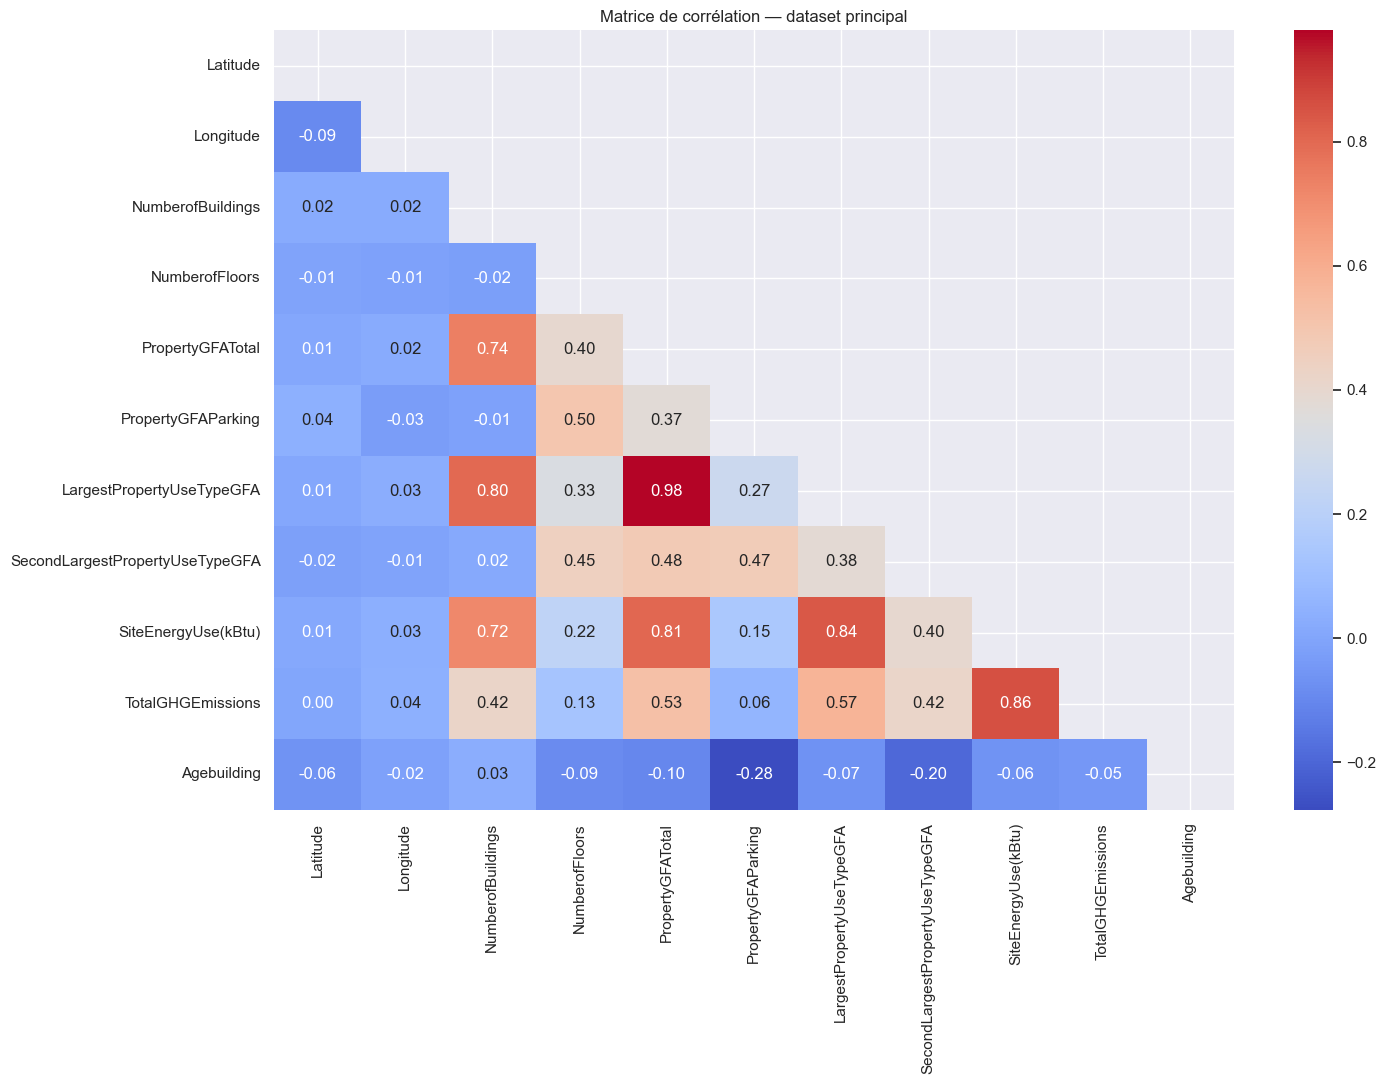

In [21]:
eda_data = data_without_score.copy()

num_cols = eda_data.select_dtypes(include=['number']).columns
corr = eda_data[num_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(15, 11))
sns.heatmap(corr, annot=True, fmt='.2f', mask=mask, cmap='coolwarm', ax=ax)
plt.title('Matrice de corrélation — dataset principal')
plt.tight_layout()
plt.show()

### 9.2 Distribution des variables numériques

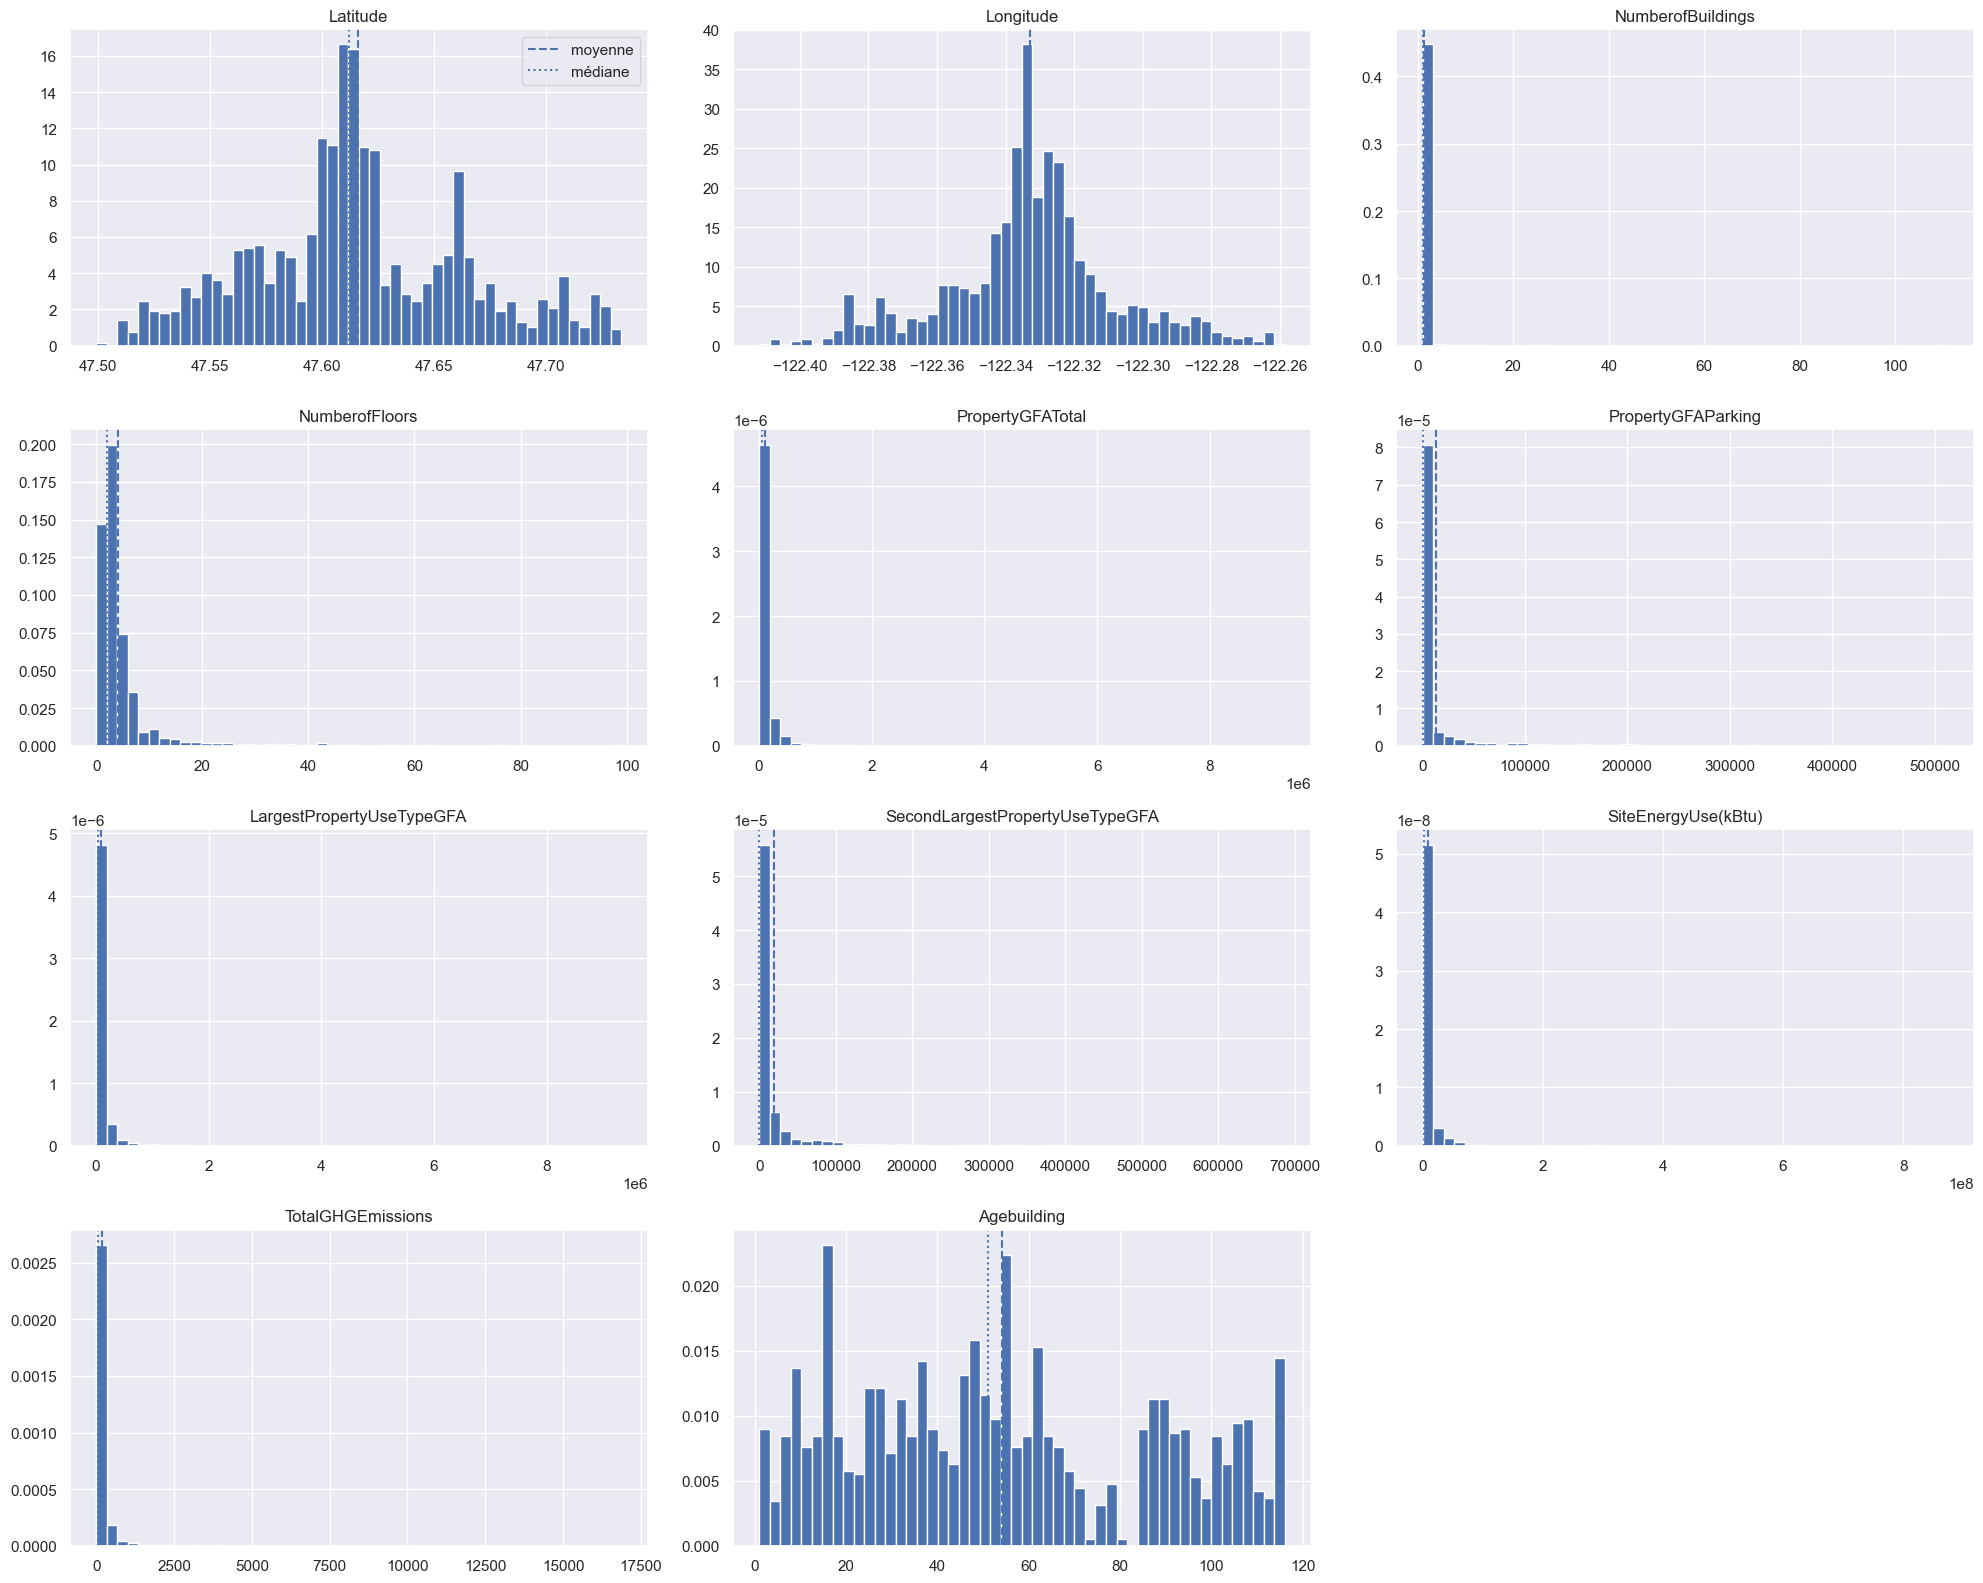

In [22]:
n = len(num_cols)
cols = 3
rows = math.ceil(n / cols)

fig, axes = plt.subplots(rows, cols, figsize=(20, rows * 4))
axes = axes.flatten()

for i, feat in enumerate(num_cols):
    axes[i].hist(eda_data[feat], bins=50, density=True)
    axes[i].axvline(eda_data[feat].mean(), ls='--', label='moyenne')
    axes[i].axvline(eda_data[feat].median(), ls=':', label='médiane')
    axes[i].set_title(feat)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

axes[0].legend()
plt.tight_layout()
plt.show()

### 9.3 Transformation logarithmique des cibles

/var/folders/5v/ky15rjln44q9l9x27dwf5jmm0000gn/T/ipykernel_49304/1271244422.py:33: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()


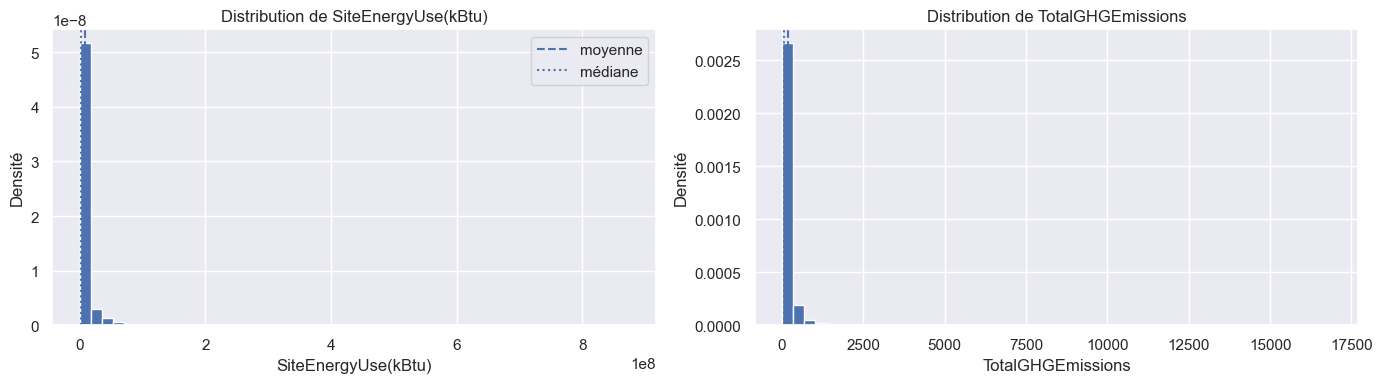

In [27]:
import math
import matplotlib.pyplot as plt

target_cols = [
    "SiteEnergyUse(kBtu)",
    "TotalGHGEmissions"
]

# Sécurité : garder uniquement les colonnes présentes dans eda_data
target_cols = [col for col in target_cols if col in eda_data.columns]

n = len(target_cols)
cols = 2
rows = math.ceil(n / cols)

fig, axes = plt.subplots(rows, cols, figsize=(14, rows * 4))

# Cas où il n'y a qu'une seule ligne ou un seul graphique
axes = axes.flatten() if n > 1 else [axes]

for i, target in enumerate(target_cols):
    axes[i].hist(eda_data[target].dropna(), bins=50, density=True)
    axes[i].axvline(eda_data[target].mean(), ls='--', label='moyenne')
    axes[i].axvline(eda_data[target].median(), ls=':', label='médiane')
    axes[i].set_title(f"Distribution de {target}")
    axes[i].set_xlabel(target)
    axes[i].set_ylabel("Densité")

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

axes[0].legend()
plt.tight_layout()
plt.show()

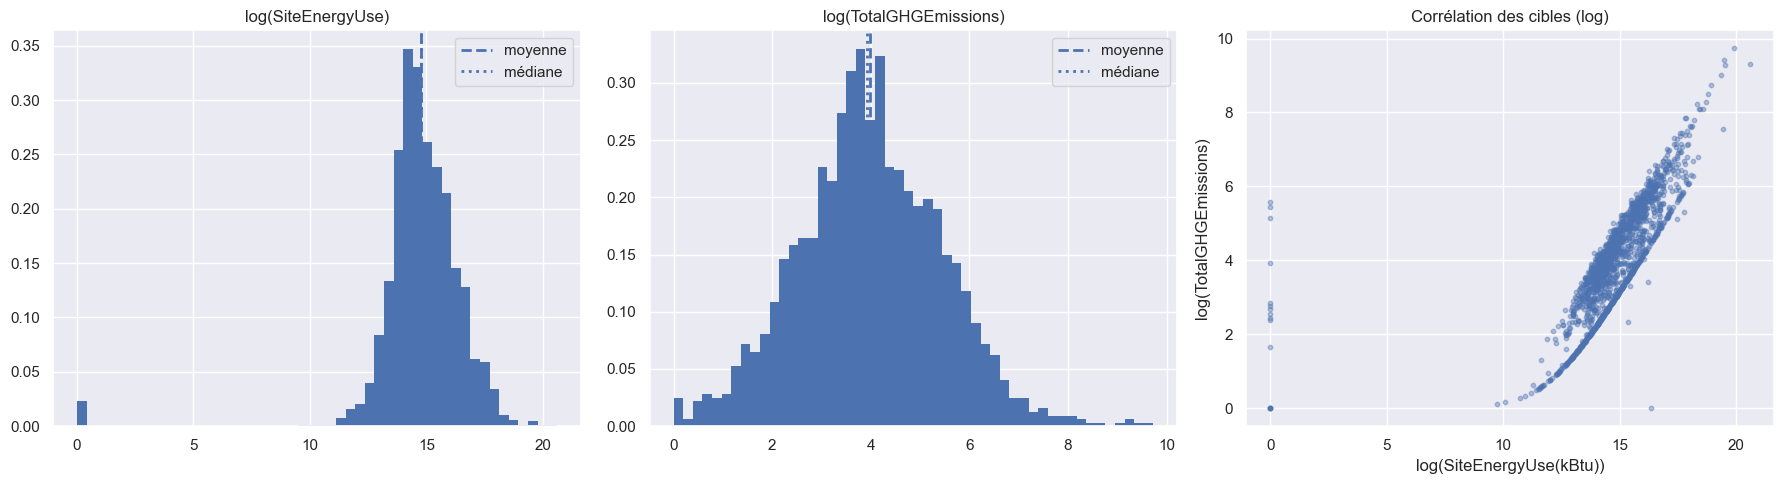

Corrélation log-cibles : 0.669


In [23]:
log_energy = np.log1p(eda_data['SiteEnergyUse(kBtu)'])
log_ghg = np.log1p(eda_data['TotalGHGEmissions'])

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, x, title in zip(
    axes[:2],
    [log_energy, log_ghg],
    ['log(SiteEnergyUse)', 'log(TotalGHGEmissions)']
):
    ax.hist(x, bins=50, density=True, edgecolor='none')
    ax.axvline(x.mean(), ls='--', lw=2, label='moyenne')
    ax.axvline(x.median(), ls=':', lw=2, label='médiane')
    ax.set_title(title)
    ax.legend()

axes[2].scatter(log_energy, log_ghg, alpha=0.4, s=10)
axes[2].set_xlabel('log(SiteEnergyUse(kBtu))')
axes[2].set_ylabel('log(TotalGHGEmissions)')
axes[2].set_title('Corrélation des cibles (log)')

plt.tight_layout()
plt.show()

print(f"Corrélation log-cibles : {log_energy.corr(log_ghg):.3f}")

### 9.4 Cibles selon les variables catégorielles

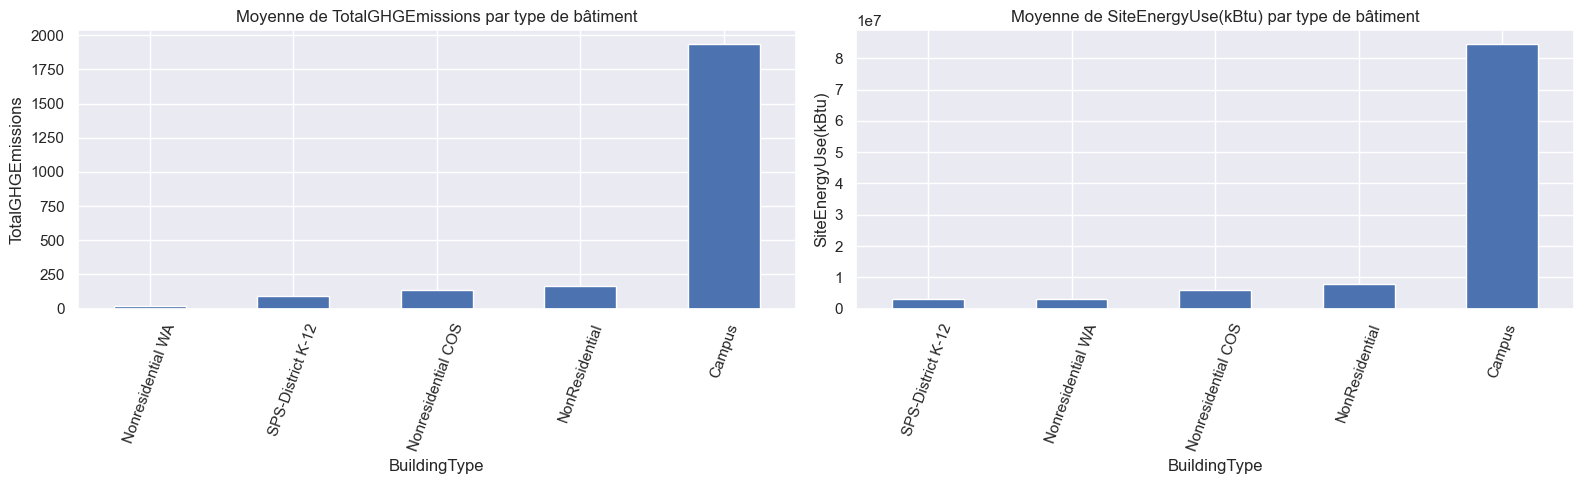

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, target in zip(axes, ['TotalGHGEmissions', 'SiteEnergyUse(kBtu)']):
    mean_by_type = eda_data.groupby('BuildingType')[target].mean().sort_values()
    mean_by_type.plot(kind='bar', ax=ax)
    ax.set_title(f'Moyenne de {target} par type de bâtiment')
    ax.tick_params(axis='x', rotation=70)
    ax.set_xlabel('BuildingType')
    ax.set_ylabel(target)

plt.tight_layout()
plt.show()

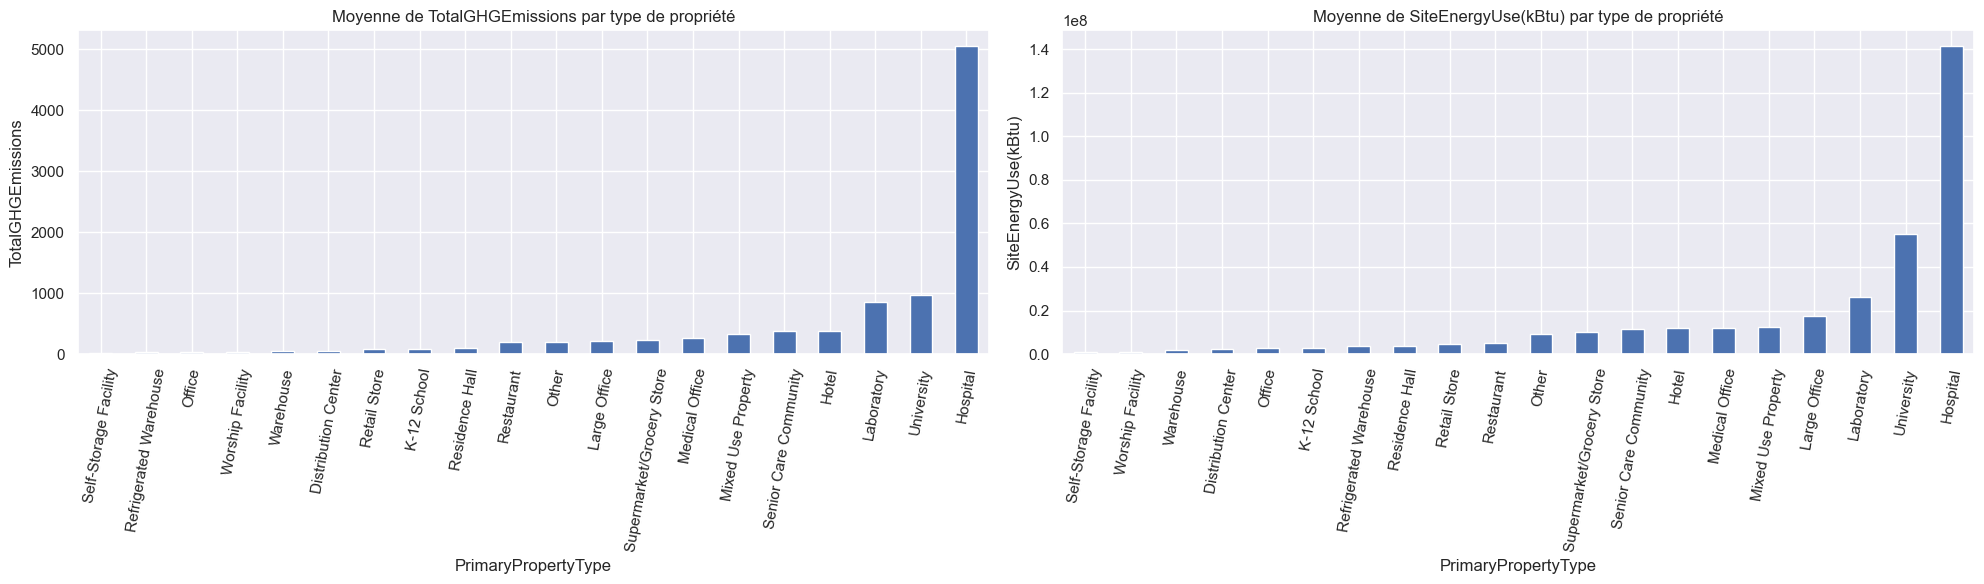

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(20, 6))

for ax, target in zip(axes, ['TotalGHGEmissions', 'SiteEnergyUse(kBtu)']):
    mean_by_type = eda_data.groupby('PrimaryPropertyType')[target].mean().sort_values()
    mean_by_type.plot(kind='bar', ax=ax)
    ax.set_title(f'Moyenne de {target} par type de propriété')
    ax.tick_params(axis='x', rotation=80)
    ax.set_xlabel('PrimaryPropertyType')
    ax.set_ylabel(target)

plt.tight_layout()
plt.show()

In [ ]:
eda_data['LargestPropertyUseType'].value_counts().head(15).sort_values().plot(
    kind='barh',
    figsize=(9, 6)
)

plt.title("Top 15 types d'usage des propriétés")
plt.xlabel('Nombre de bâtiments')
plt.tight_layout()
plt.show()

## 10. Export des datasets nettoyés

Deux fichiers sont exportés :

- `Cleaned_Batiment_energie_without_score.csv` : dataset principal, sans `ENERGYSTARScore` ;
- `Cleaned_Batiment_energie_with_score.csv` : dataset secondaire, avec `ENERGYSTARScore`.

Ces fichiers seront utilisés dans le notebook de modélisation.

In [26]:
data_without_score.to_csv("Cleaned_Batiment_energie_without_score.csv", index=False)
data_with_score.to_csv("Cleaned_Batiment_energie_with_score.csv", index=False)

print("Fichiers sauvegardés :")
print("- Cleaned_Batiment_energie_without_score.csv")
print("- Cleaned_Batiment_energie_with_score.csv")

print("\nColonnes finales du dataset principal :")
print(list(data_without_score.columns))

Fichiers sauvegardés :
- Cleaned_Batiment_energie_without_score.csv
- Cleaned_Batiment_energie_with_score.csv

Colonnes finales du dataset principal :
['BuildingType', 'PrimaryPropertyType', 'Latitude', 'Longitude', 'NumberofBuildings', 'NumberofFloors', 'PropertyGFATotal', 'PropertyGFAParking', 'LargestPropertyUseType', 'LargestPropertyUseTypeGFA', 'SecondLargestPropertyUseType', 'SecondLargestPropertyUseTypeGFA', 'SiteEnergyUse(kBtu)', 'TotalGHGEmissions', 'Agebuilding']
